# Final Code

#### 1. Import Libraries and Define Parameters

In [1]:
from fipy import (
    CellVariable,
    FaceVariable,
    Grid1D,
    DiffusionTerm,
    PowerLawConvectionTerm,
    ImplicitSourceTerm
)
import numpy as np
import matplotlib.pyplot as plt

L = 1.0
nx = 100
dx = L / nx
max_sweeps, coupling_tolerance = 100, 1e-8
Vapp = 1.0
E = 1.0   
kB = 1.380649e-23      
q  = 1.602176634e-19   
a_hop = 3.2e-10        
f_esc = 1e12           
Ea_eV = 0.85           
Ea    = Ea_eV * q      
T_op  = 300.0          

D = 0.5 * a_hop**2 * f_esc * np.exp(-Ea / (kB * T_op))
v = a_hop * f_esc * np.exp(-Ea / (kB * T_op)) * np.sinh(q * a_hop * E / (2 * kB * T_op))

#### 2. Create Mesh, Variables, and Boundary Conditions

In [2]:
mesh = Grid1D(nx=nx, dx=dx)
x = mesh.cellCenters[0]

phi = CellVariable(name="Electric Potential", mesh=mesh, value=np.sin(np.pi*x))
T = CellVariable(name="Temperature", mesh=mesh, value=np.sin(np.pi*x), hasOld=True)
p = CellVariable(name="Carrier Concentration", mesh=mesh, value=np.sin(np.pi*x), hasOld=True)

T.constrain(300.0, mesh.facesLeft)
T.constrain(300.0, mesh.facesRight)

phi.constrain(0.0, mesh.facesLeft)
phi.constrain(Vapp, mesh.facesRight)

p.faceGrad.constrain((0.,), mesh.facesLeft)
p.faceGrad.constrain((0.,), mesh.facesRight)

d = dx / 2.0
v_phys = (v / D)

fluxCoeff = FaceVariable(mesh=mesh, rank=1, value=(v_phys,))

fluxCoeff.setValue((2.0 * v_phys / (1.0 + v_phys * d),), where=mesh.facesLeft)
fluxCoeff.setValue((2.0 * v_phys / (1.0 - v_phys * d),), where=mesh.facesRight)

#### 2b. Physical Functions and Derived Parameters


In [3]:
rho = 8200.0            
Cp  = 26.0              # heat capacity [J/(kg K)]
e   = q                 # elementary charge [C], as used in the drift/Joule-heating terms

T0_room = 293.0          # room-temperature reference, T0 (Table S1)
lam_th  = 0.1            # linear thermal-conductivity coefficient, lambda (Table S1)

# --- Soret coefficient, main text Eq. 2: S = -Ea / (kB T^2) ---
def S_of_T(T):
    return -Ea / (kB * T**2)

S = S_of_T(T_op)

# --- Electrical conductivity, Eq. 1: sigma = sigma0(nD) exp(-Eac(nD)/kT) + sigma_PF(E,T) ---
# sigma0(nD): linearly increases from 1 S/m (nD -> 0) to 1e5 S/m (nD = 1e22 cm^-3) (main text, Sec. 2.1)
nD_max_cm3 = 1e22
def sigma0_of_nD(nD_cm3):
    return np.interp(nD_cm3, [0.0, nD_max_cm3], [1.0, 1e5])

# Eac(nD): piecewise-linear activation energy [eV] (main text / Figure S2a)
_nD_pts_cm3 = [0.0, 1e20, 5e21, 1e22]
_Eac_pts_eV = [0.20, 0.10, 0.00, -0.006]
def Eac_of_nD(nD_cm3):
    return np.interp(nD_cm3, _nD_pts_cm3, _Eac_pts_eV) * q   # [J]

# Poole-Frenkel conduction term, Eq. 1: sigma_PF(E,T) = exp(293/T (alpha*sqrt(E) + beta))
# alpha, beta from Table S1 (PF coefficient 1, PF coefficient 2). E is assumed in V/cm,
# the standard convention for this empirical PF fit (paper does not state units explicitly).
alpha_PF = 5.48e-4      # PF coefficient 1 (Table S1)
beta_PF  = -5.70        # PF coefficient 2 (Table S1)
def sigma_PF(E_Vcm, T):
    return np.exp(293.0 / T * (alpha_PF * np.sqrt(np.abs(E_Vcm)) + beta_PF))

def sigma_of_nD_T(nD_cm3, T, E_Vcm=0.0):
    return sigma0_of_nD(nD_cm3) * np.exp(-Eac_of_nD(nD_cm3) / (kB * T)) + sigma_PF(E_Vcm, T)

nD_reservoir_cm3 = 1e22
# Conductive TaOx (VO reservoir) layer, nD = 1e22 cm^-3 (main text, Sec. 2.1)
sigma = sigma_of_nD_T(nD_reservoir_cm3, T_op, E_Vcm=E)   # Eq. 1 (both terms), evaluated directly

# --- Thermal conductivity, Table S1: k = kth0(nD) (1 + lambda (T - T0)) ---
# kth0(nD): linear interpolation between the two points read from Figure S2b
_nD_pts_kth_cm3 = [0.0, 1e22]
_kth0_pts = [0.0, 58.0]   # W/(m K)
def kth0_of_nD(nD_cm3):
    return np.interp(nD_cm3, _nD_pts_kth_cm3, _kth0_pts)

def km_of_nD_T(nD_cm3, T):
    return kth0_of_nD(nD_cm3) * (1.0 + lam_th * (T - T0_room))

km = kth0_of_nD(nD_reservoir_cm3)   # thermal conductivity at nD = 1e22 cm^-3, T ~ T0 [W/(m K)]

# --- Verification: re-derive D and mu_p using the same functional forms as Cell 1 ---
def D_of_T(T):
    return 0.5 * a_hop**2 * f_esc * np.exp(-Ea / (kB * T))

def mu_of_T(T):
    return q * D_of_T(T) / (kB * T)

print(f"D(T_op)    = {D_of_T(T_op):.4e} m^2/s      (Cell-1 value: {D:.4e} m^2/s)")
print(f"S(T_op)    = {S_of_T(T_op):.4e} 1/K")
print(f"sigma (Eq. 1, nD=1e22 cm^-3) = {sigma:.4e} S/m")
print(f"km (nD=1e22 cm^-3)           = {km:.4e} W/(m K)")


D(T_op)    = 2.6909e-22 m^2/s      (Cell-1 value: 2.6909e-22 m^2/s)
S(T_op)    = -1.0960e-01 1/K
sigma (Eq. 1, nD=1e22 cm^-3) = 1.2612e+05 S/m
km (nD=1e22 cm^-3)           = 5.8000e+01 W/(m K)


#### 3. Solve the Coupled Electro-Thermal-Carrier Model

In [6]:
converged = False

for sweep in range(max_sweeps):

    phi_iter = CellVariable(name="phi iteration", mesh=mesh, value=phi.value.copy())
    T_iter = CellVariable(name="T iteration", mesh=mesh, value=T.value.copy())
    p_iter = CellVariable(name="p iteration", mesh=mesh, value=p.value.copy())

    E_field = -phi_iter.grad[0]
    E_face = E_field.arithmeticFaceValue
    V = FaceVariable(mesh=mesh, rank=1, value=(v,))
    electrical_eq = (DiffusionTerm(coeff=sigma, var=phi) == 0)

    T_grad_iter = T_iter.faceGrad
    therm_diffusion_T = DiffusionTerm(coeff=D * S * p_iter, var=T)
    therm_diffusion_p = PowerLawConvectionTerm(coeff=D * S * T_grad_iter, var=p)
    correction_flux = (p_iter.faceValue * T_iter.faceGrad)
    correction_term = (D * S * correction_flux.divergence)
    ambipolar_eq = (DiffusionTerm(coeff=D, var=p) - PowerLawConvectionTerm(coeff=V, var=p) + therm_diffusion_T + therm_diffusion_p - correction_term == 0)

    # drift_heat = ImplicitSourceTerm(coeff=e * V * E_field, var=p)
    # diffusion_heat = PowerLawConvectionTerm(coeff=-e * D * E_face, var=p)
    # heat_eq = (DiffusionTerm(coeff=km / (rho * Cp), var=T) + (drift_heat + diffusion_heat) / (rho * Cp) == 0)

    Jp = e * p_iter * v - e * D * p_iter.grad[0]

    heat_source = Jp * E_field

    heat_eq = (
        DiffusionTerm(coeff=km / (rho * Cp), var=T)
        + heat_source / (rho * Cp)
        == 0
    )



    coupled_eq = (electrical_eq & heat_eq & ambipolar_eq)
    coupled_eq.solve()

    phi_change = np.max(np.abs(phi.value - phi_iter.value))
    T_change = np.max(np.abs(T.value - T_iter.value))
    p_change = np.max(np.abs(p.value - p_iter.value))
    max_change = max(phi_change, T_change, p_change)

    del phi_iter, T_iter, p_iter

    if max_change < coupling_tolerance:
        converged = True
        break

#### 4. Calculate Final Quantities and Display Results

In [7]:
E_final = -phi.grad[0]
dpdx = p.grad[0]
Jp_final = (e * v * p - e * D * dpdx)
Q_final = Jp_final * E_final

results = {"Electric potential (φ)": phi.value, "Electric field (E)": E_final.value, "Temperature (T)": T.value, "Carrier concentration (p)": p.value, "Current density (J)": Jp_final.value, "Joule heating (Q)": Q_final.value}

for name, data in results.items():print(f"{name}: " f"min = {np.min(data):.4e}, " f"max = {np.max(data):.4e}")

Electric potential (φ): min = 5.0000e-03, max = 9.9500e-01
Electric field (E): min = -1.0000e+00, max = -1.0000e+00
Temperature (T): min = 3.0000e+02, max = 3.0000e+02
Carrier concentration (p): min = 9.1799e-02, max = 9.9406e-02
Current density (J): min = 1.5300e-40, max = 1.6587e-40
Joule heating (Q): min = -1.6587e-40, max = -1.5300e-40


#### 5. Plot the Results

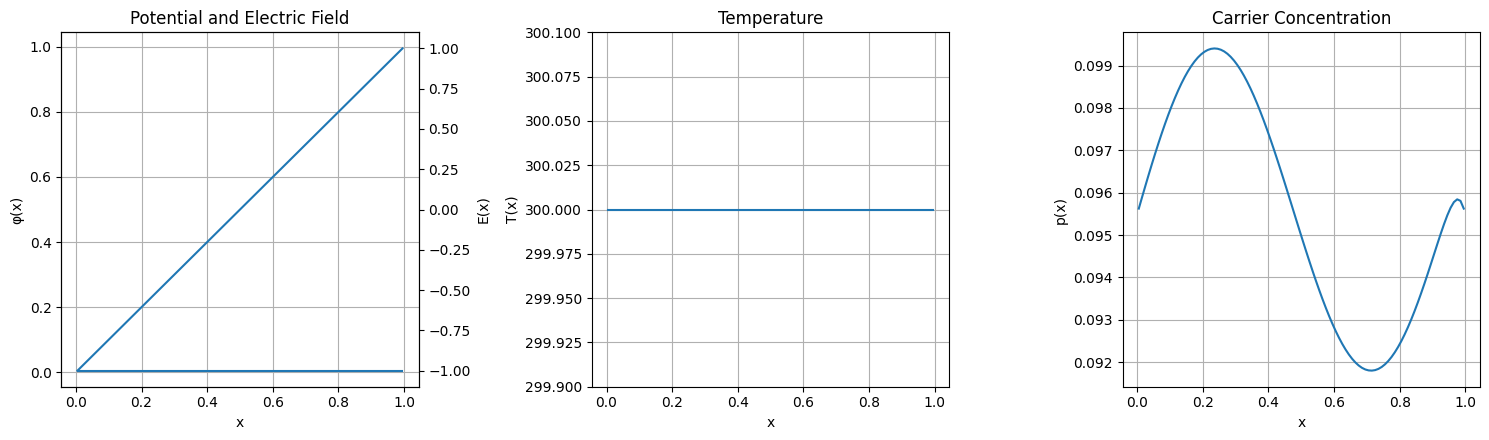

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

ax1 = axes[0]
ax1.plot(x.value, phi.value)
ax1.set(xlabel="x", ylabel="φ(x)", title="Potential and Electric Field")
ax1.grid(True)

ax2 = ax1.twinx()
ax2.plot(x.value, E_final.value)
ax2.set_ylabel("E(x)")
ax2.set_ylim(-1.1, 1.1)

for ax, y, label, title in zip(axes[1:], [T.value, p.value], ["T(x)", "p(x)"], ["Temperature", "Carrier Concentration"]):
    ax.plot(x.value, y)
    ax.set(xlabel="x", ylabel=label, title=title)
    ax.grid(True)

axes[1].set_ylim(299.9, 300.1)
axes[1].ticklabel_format(axis='y', style='plain', useOffset=False)

plt.tight_layout()
plt.show()